# Benchmark - [Google's Gemma 4 26B](https://huggingface.co/unsloth/gemma-4-26B-A4B-it-qat-GGUF)

**Evaluation:** Tasks 01-06, excl. 03

**Hardware:** Apple M5 Max 128GB

In [12]:
import textwrap

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

from benchmark_lib import (
  DATA_DIR,
  RUNS_PER_BATCH,
  SERIES,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  plot_timeouts,
  save_runs,
)

HARDWARE = "Apple M5 Max 128GB"
MODEL_LABEL = "Gemma 4 26B"


In [2]:
MODEL_NAME = "gemma-4-26b-a4b"
benchmark_dir = DATA_DIR / "google" / MODEL_NAME

if (not benchmark_dir.exists()):
  all_runs = load_runs(model=MODEL_NAME, hardware=HARDWARE)
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir, redact=("openai",))


In [4]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark.head()


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260815_160627,2026-08-15 16:06:27.816009,True,0.8,4.0,5,False,True,349,...,gemma-4-26B-A4B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",23057,18092,732900,0,774049
1,01-data-loading,20260815_161217,2026-08-15 16:12:17.958471,True,1.0,5.0,5,True,True,163,...,gemma-4-26B-A4B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",12722,10005,290343,0,313070
2,01-data-loading,20260815_161501,2026-08-15 16:15:01.853894,True,1.0,5.0,5,True,True,153,...,gemma-4-26B-A4B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",13541,8382,289700,0,311623
3,01-data-loading,20260815_161735,2026-08-15 16:17:35.054776,True,0.8,4.0,5,False,True,214,...,gemma-4-26B-A4B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",21165,11320,357454,0,389939
4,01-data-loading,20260815_162109,2026-08-15 16:21:09.763885,True,1.0,5.0,5,True,True,220,...,gemma-4-26B-A4B-Q4_K_XL,pi,llama.cpp,Apple M5 Max 128GB,"{'n_cells': {'expected': 20857, 'actual': 2085...",17707,12237,356041,0,385985


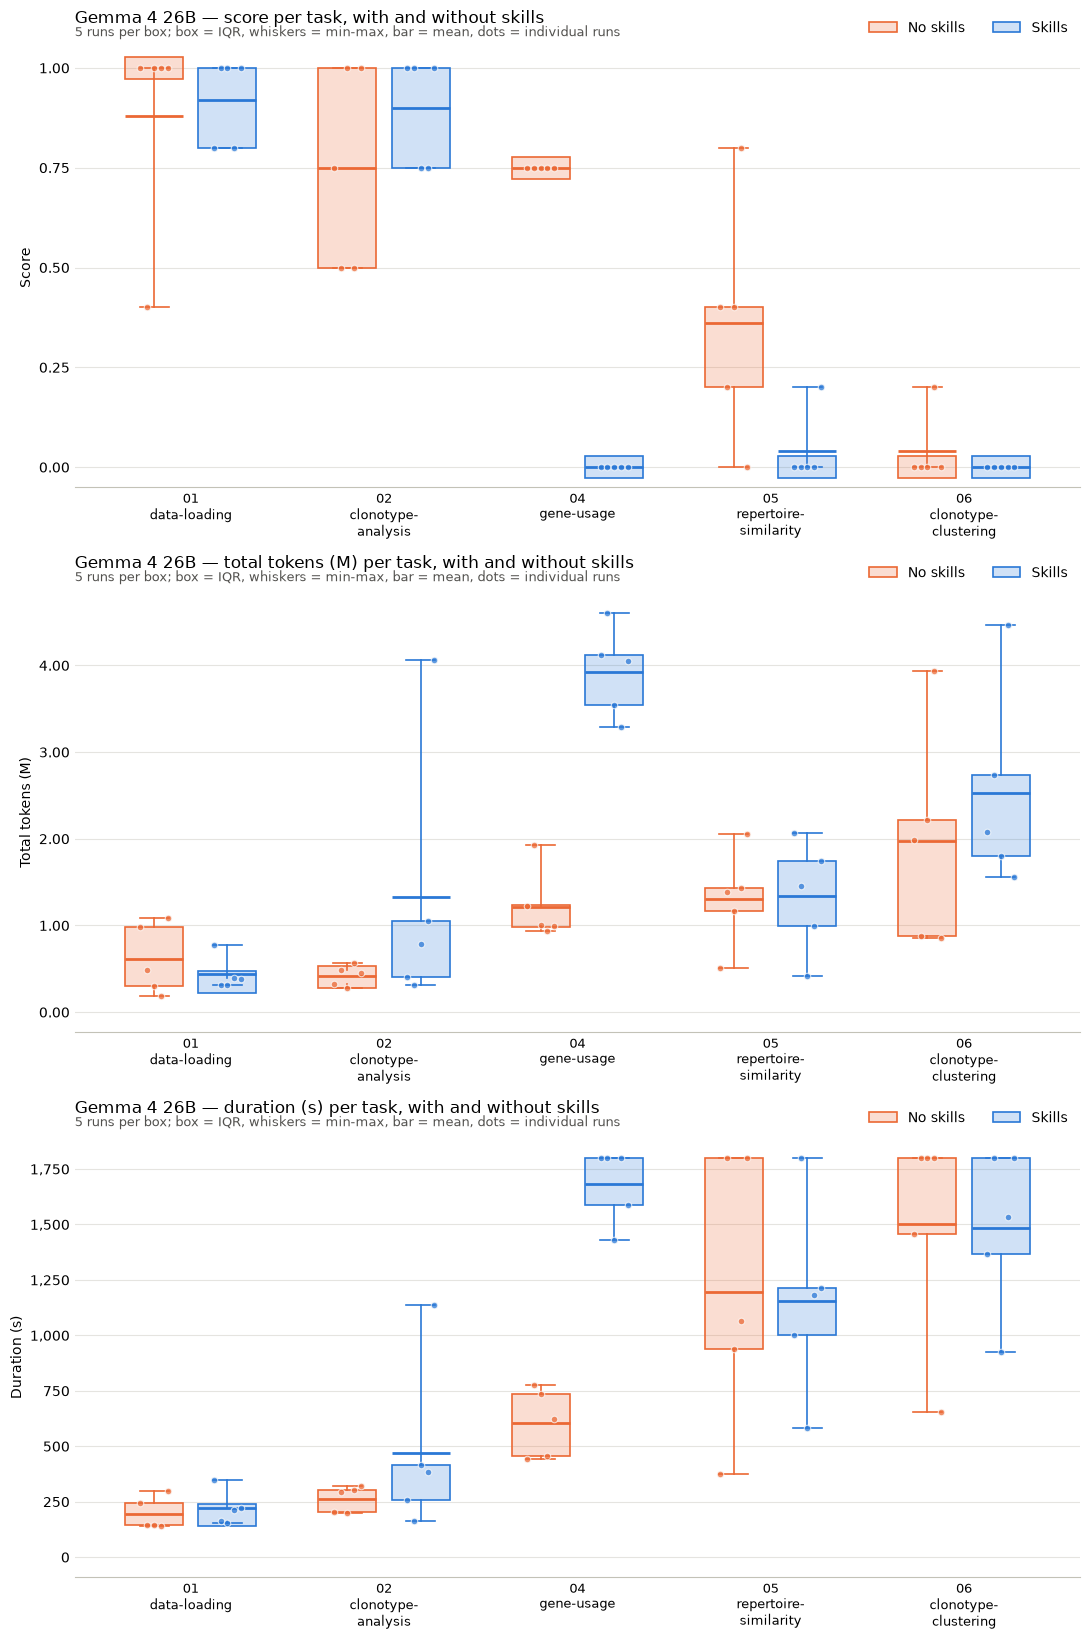

In [5]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


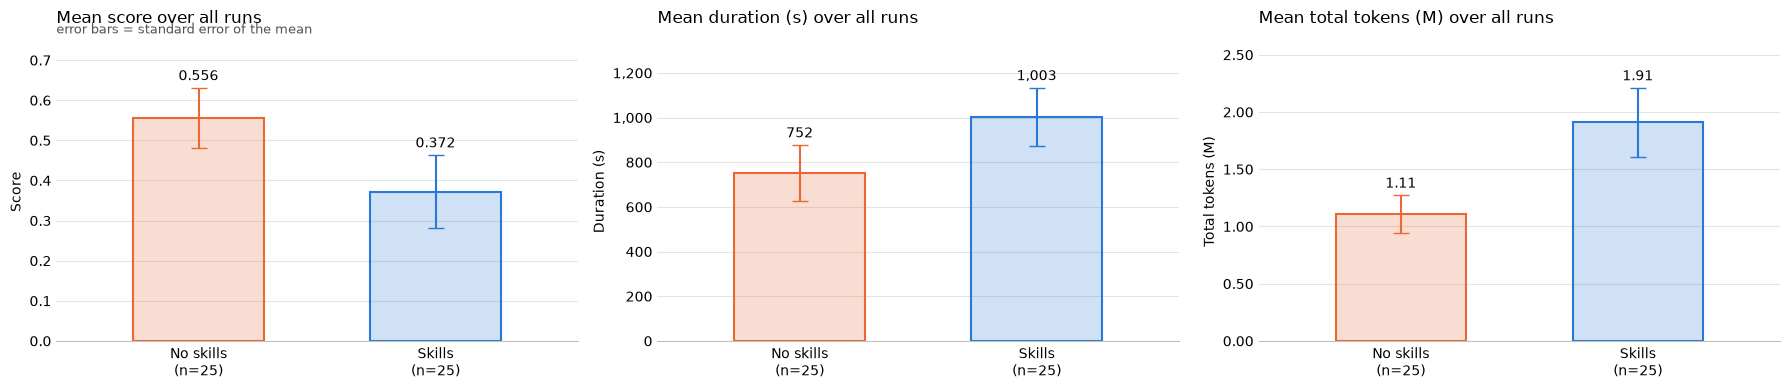

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [7]:
significance = compare_skills(benchmark)


In [8]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,25 vs 25,0.556,0.372,-0.184,0.146759,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,0.880,0.920,0.040,0.796253,0.796253,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,0.750,0.900,0.150,0.364346,0.529638,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,0.750,0.000,-0.750,0.003977,0.019884,True
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.360,0.040,-0.320,0.056483,0.141207,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,0.040,0.000,-0.040,0.423711,0.529638,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,0.556,0.372,-0.184,0.437500,NaN,False


In [9]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,25 vs 25,752.32,1002.92,250.6,0.226516,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,194.00,219.80,25.8,0.420635,0.701058,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,263.20,471.00,207.8,0.420635,0.701058,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,606.40,1683.40,1077.0,0.011159,0.055797,False
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,1195.40,1155.40,-40.0,1.000000,1.000000,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,1502.60,1485.00,-17.6,0.823664,1.000000,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,752.32,1002.92,250.6,0.437500,NaN,False


In [10]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,25 vs 25,1106070.64,1908886.04,802815.4,0.111602,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,608959.80,434933.20,-174026.6,0.841270,0.841270,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,419300.40,1325832.20,906531.8,0.309524,0.773810,False
3,04-gene-usage,Mann-Whitney U,5 vs 5,1216331.80,3920482.60,2704150.8,0.007937,0.039683,True
4,05-repertoire-similarity,Mann-Whitney U,5 vs 5,1310952.60,1335670.80,24718.2,0.841270,0.841270,False
5,06-clonotype-clustering,Mann-Whitney U,5 vs 5,1974808.60,2527511.40,552702.8,0.547619,0.841270,False
6,all tasks (paired by task),Wilcoxon signed-rank,5 tasks,1106070.64,1908886.04,802815.4,0.187500,NaN,False


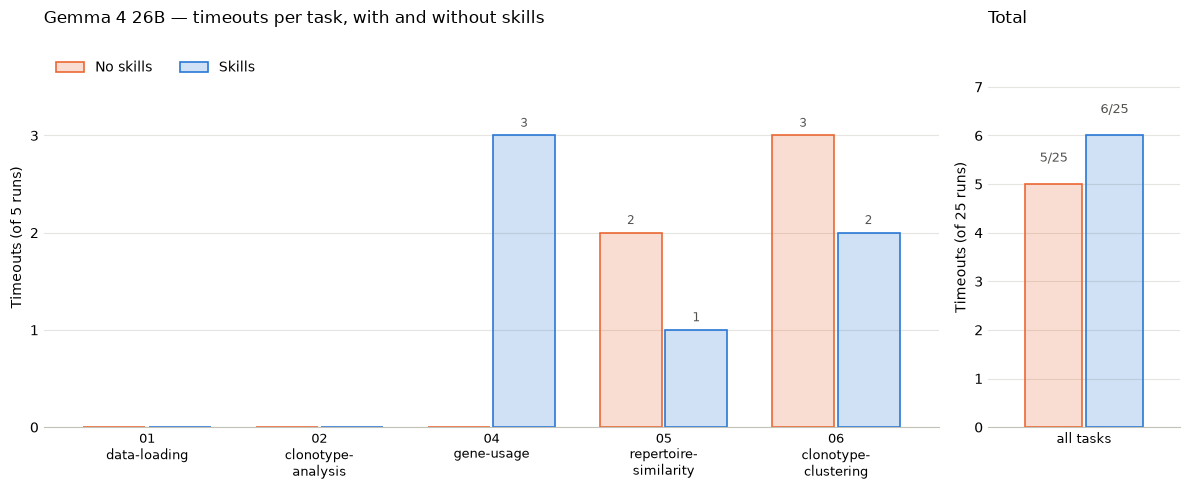

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_timeouts(benchmark, model_label=MODEL_LABEL, axs=axs)
fig.tight_layout()
plt.show()